In [1]:
!pip install xgboost shap imbalanced-learn scikit-learn pandas matplotlib joblib

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [imbalanced-learn][imbalanced-learn]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
amazon-sa

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, classification_report
import xgboost as xgb
import shap
import joblib

In [3]:
# LOAD THE EXACT DATASETS
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

# ISOLATE TARGETS: KEEP ATTACK_CAT FOR SMOTE, KEEP LABEL FOR FINAL TEST
y_train_cat = train_df['attack_cat']
y_test_binary = test_df['label']

# DEFINE COLUMNS TO DROP FROM FEATURES
cols_to_drop = ['id', 'label', 'attack_cat']
identifiers = ['srcip', 'dstip', 'stime', 'ltime']
for col in identifiers:
    if col in train_df.columns:
        cols_to_drop.append(col)

X_train = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
X_test = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

# FILL MISSING CATEGORIES
X_train.fillna('None', inplace=True)
X_test.fillna('None', inplace=True)
y_train_cat.fillna('Normal', inplace=True)  # ENSURE NORMAL TRAFFIC HAS A CATEGORY

print("STEP 2 COMPLETE. DATA LOADED AND TARGETS ISOLATED.")

STEP 2 COMPLETE. DATA LOADED AND TARGETS ISOLATED.


In [4]:
# DEFINE CATEGORICAL COLUMNS
categorical_cols = ['proto', 'state', 'service']

# APPLY ONE HOT ENCODING
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

# MAKE SURE TRAIN AND TEST SETS HAVE THE EXACT SAME COLUMNS
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# APPLY STANDARD SCALER
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("STEP 3 COMPLETE. DATA ENCODED AND SCALED.")

STEP 3 COMPLETE. DATA ENCODED AND SCALED.


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# APPLY SMOTE ON THE MULTI-CLASS CATEGORIES TO PROPERLY BALANCE RARE ATTACKS
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced_cat = smote.fit_resample(X_train_scaled, y_train_cat)

# CONVERT BALANCED CATEGORIES BACK TO BINARY
# 0 = Normal traffic, 1 = Attack traffic
y_train_balanced_binary = (y_train_balanced_cat != 'Normal').astype(int)

# TRAIN THE TUNED XGBOOST MODEL
xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    max_depth=8,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_balanced, y_train_balanced_binary)

# MAKE PREDICTIONS ON THE TEST SET
y_pred = xgb_model.predict(X_test_scaled)

# PRINT RESULTS FOR THE REPORT
print("XGBOOST ACCURACY:", accuracy_score(y_test_binary, y_pred))
print("XGBOOST PRECISION:", precision_score(y_test_binary, y_pred))
print("XGBOOST RECALL:", recall_score(y_test_binary, y_pred))
print("XGBOOST F1 SCORE:", f1_score(y_test_binary, y_pred))
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test_binary, y_pred))

print("STEP 4 COMPLETE. TUNED XGBOOST MODEL TRAINED AND EVALUATED.")

XGBOOST ACCURACY: 0.9027494995465978
XGBOOST PRECISION: 0.9861228602115789
XGBOOST RECALL: 0.8693491758909344
XGBOOST F1 SCORE: 0.924061456245825

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.78      0.97      0.86     56000
           1       0.99      0.87      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.91    175341

STEP 4 COMPLETE. TUNED XGBOOST MODEL TRAINED AND EVALUATED.


In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,          
    max_depth=5,              
    min_samples_split=10,     
    min_samples_leaf=5,
    class_weight='balanced',        
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_balanced, y_train_balanced_binary)

# MAKE PREDICTIONS ON THE TEST SET
y_pred_rf = rf_model.predict(X_test_scaled)

# PRINT RESULTS FOR THE REPORT
print("RANDOM FOREST ACCURACY:", accuracy_score(y_test_binary, y_pred_rf))
print("RANDOM FOREST PRECISION:", precision_score(y_test_binary, y_pred_rf))
print("RANDOM FOREST RECALL:", recall_score(y_test_binary, y_pred_rf))
print("RANDOM FOREST F1 SCORE:", f1_score(y_test_binary, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_rf))

RANDOM FOREST ACCURACY: 0.9028293439640472
RANDOM FOREST PRECISION: 0.9646799116997793
RANDOM FOREST RECALL: 0.8898115484200736
RANDOM FOREST F1 SCORE: 0.9257344608142272

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86     56000
           1       0.96      0.89      0.93    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.91      0.89    175341
weighted avg       0.91      0.90      0.90    175341



In [7]:
dt_model = DecisionTreeClassifier(
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train_balanced, y_train_balanced_binary)

# MAKE PREDICTIONS ON THE TEST SET
y_pred_dt = dt_model.predict(X_test_scaled)

# PRINT RESULTS FOR THE REPORT
print("DECISION TREE ACCURACY:", accuracy_score(y_test_binary, y_pred_dt))
print("DECISION TREE PRECISION:", precision_score(y_test_binary, y_pred_dt))
print("DECISION TREE RECALL:", recall_score(y_test_binary, y_pred_dt))
print("DECISION TREE F1 SCORE:", f1_score(y_test_binary, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_dt))

DECISION TREE ACCURACY: 0.8822066715713952
DECISION TREE PRECISION: 0.9880710986260992
DECISION TREE RECALL: 0.8370384025607294
DECISION TREE F1 SCORE: 0.9063055706768282

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.98      0.84     56000
           1       0.99      0.84      0.91    119341

    accuracy                           0.88    175341
   macro avg       0.86      0.91      0.87    175341
weighted avg       0.91      0.88      0.89    175341



In [8]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_balanced, y_train_balanced_binary)

# MAKE PREDICTIONS ON THE TEST SET
y_pred_lr = lr_model.predict(X_test_scaled)

# PRINT RESULTS FOR THE REPORT
print("LOGISTIC REGRESSION ACCURACY:", accuracy_score(y_test_binary, y_pred_lr))
print("LOGISTIC REGRESSION PRECISION:", precision_score(y_test_binary, y_pred_lr))
print("LOGISTIC REGRESSION RECALL:", recall_score(y_test_binary, y_pred_lr))
print("LOGISTIC REGRESSION F1 SCORE:", f1_score(y_test_binary, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_lr))


LOGISTIC REGRESSION ACCURACY: 0.8883832075783759
LOGISTIC REGRESSION PRECISION: 0.9819806763285024
LOGISTIC REGRESSION RECALL: 0.8516352301388458
LOGISTIC REGRESSION F1 SCORE: 0.9121750485772366

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.97      0.85     56000
           1       0.98      0.85      0.91    119341

    accuracy                           0.89    175341
   macro avg       0.87      0.91      0.88    175341
weighted avg       0.91      0.89      0.89    175341



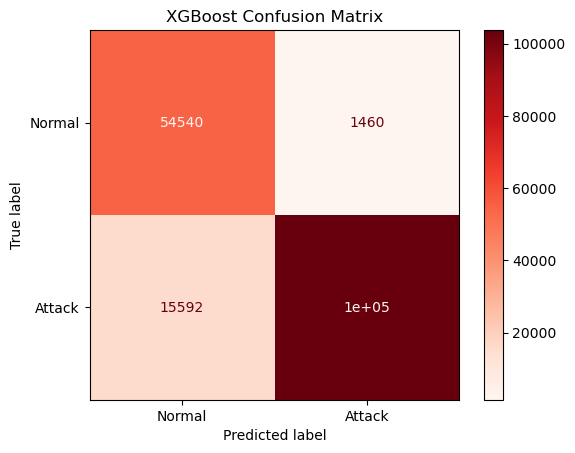

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# GENERATE CONFUSION MATRIX
cm = confusion_matrix(y_test_binary, y_pred)

# DISPLAY CONFUSION MATRIX
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Reds")

plt.title("XGBoost Confusion Matrix")
plt.show()

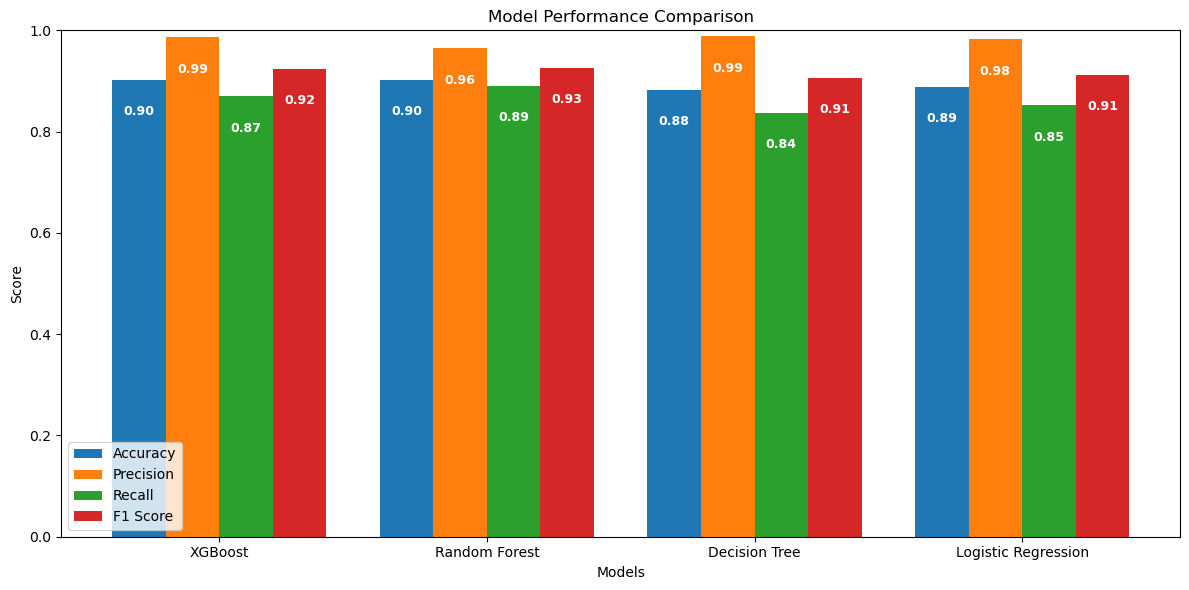

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# MODEL NAMES
models = ['XGBoost', 'Random Forest', 'Decision Tree', 'Logistic Regression']

# METRIC VALUES
accuracy = [
    accuracy_score(y_test_binary, y_pred),
    accuracy_score(y_test_binary, y_pred_rf),
    accuracy_score(y_test_binary, y_pred_dt),
    accuracy_score(y_test_binary, y_pred_lr)
]

precision = [
    precision_score(y_test_binary, y_pred),
    precision_score(y_test_binary, y_pred_rf),
    precision_score(y_test_binary, y_pred_dt),
    precision_score(y_test_binary, y_pred_lr)
]

recall = [
    recall_score(y_test_binary, y_pred),
    recall_score(y_test_binary, y_pred_rf),
    recall_score(y_test_binary, y_pred_dt),
    recall_score(y_test_binary, y_pred_lr)
]

f1 = [
    f1_score(y_test_binary, y_pred),
    f1_score(y_test_binary, y_pred_rf),
    f1_score(y_test_binary, y_pred_dt),
    f1_score(y_test_binary, y_pred_lr)
]

# BAR POSITIONS
x = np.arange(len(models))
width = 0.2

# CREATE FIGURE
plt.figure(figsize=(12, 6))

# CREATE BARS
bars1 = plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
bars2 = plt.bar(x - 0.5*width, precision, width, label='Precision')
bars3 = plt.bar(x + 0.5*width, recall, width, label='Recall')
bars4 = plt.bar(x + 1.5*width, f1, width, label='F1 Score')

# LABELS AND TITLES
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.ylim(0, 1)

# LEGEND
plt.legend()

# FUNCTION TO ADD VALUES INSIDE BARS
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height - 0.05,
            f'{height:.2f}',
            ha='center',
            va='top',
            color='white',
            fontsize=9,
            fontweight='bold'
        )

# ADD LABELS
add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.tight_layout()
plt.show()

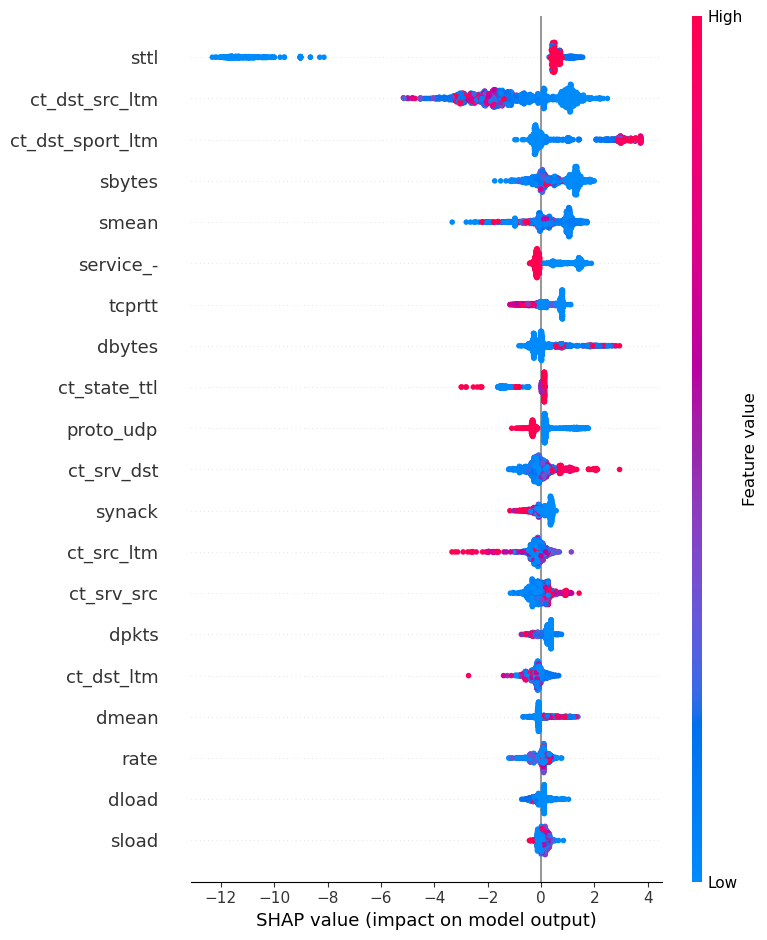

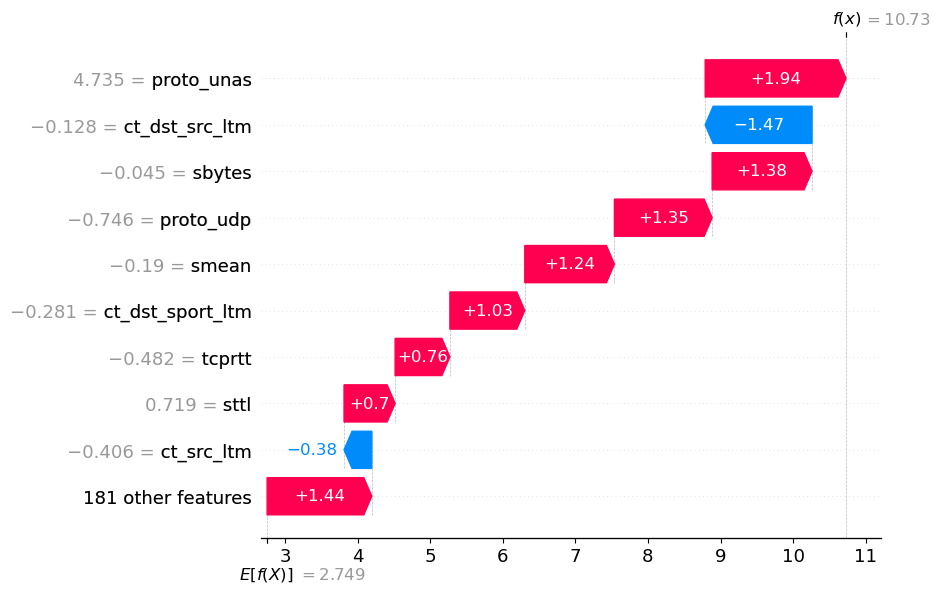

STEP 5 COMPLETE. EXPLAINABILITY PLOTS GENERATED.


In [11]:
# INITIALIZE SHAP TREE EXPLAINER
explainer = shap.TreeExplainer(xgb_model)

# SAMPLE TEST RECORDS
sample_size = min(1000, X_test_scaled.shape[0])
sample_idx = np.random.choice(X_test_scaled.shape[0], sample_size, replace=False)
X_test_sample = X_test_scaled[sample_idx]

# CALCULATE SHAP VALUES
shap_values = explainer(X_test_sample)

# GLOBAL SHAP FEATURE IMPORTANCE
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X_train_encoded.columns
)

# FIX LOCAL WATERFALL FEATURE NAMES
local_explanation = shap.Explanation(
    values=shap_values[0].values,
    base_values=shap_values[0].base_values,
    data=X_test_sample[0],
    feature_names=X_train_encoded.columns
)

# LOCAL SHAP WATERFALL WITH REAL FEATURE NAMES
shap.plots.waterfall(local_explanation)

print("STEP 5 COMPLETE. EXPLAINABILITY PLOTS GENERATED.")

In [12]:
# GET TOP CONTRIBUTING FEATURES FOR THE FIRST ALERT
feature_contributions = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'SHAP Value': shap_values[0].values
})

# SORT BY MOST IMPORTANT POSITIVE CONTRIBUTIONS
top_features = feature_contributions.sort_values(
    by='SHAP Value',
    ascending=False
).head(3)

print(top_features)

        Feature  SHAP Value
157  proto_unas    1.941788
3        sbytes    1.377180
156   proto_udp    1.347184
